Total craters found on disk: 1,021,843
Latent vector size: 50


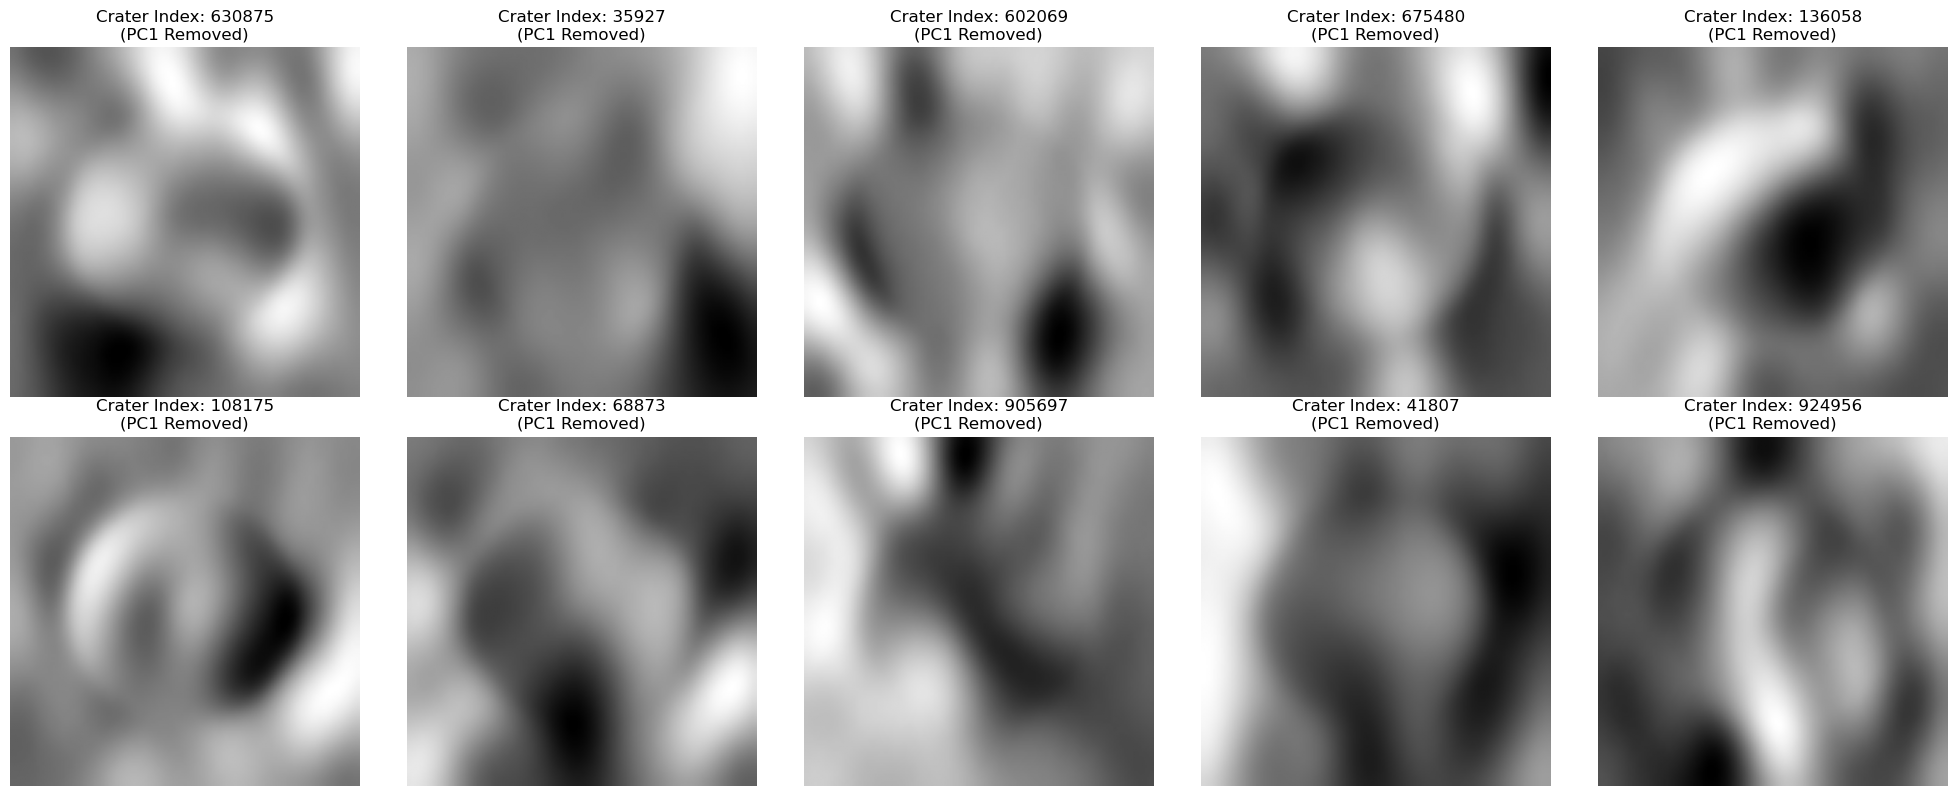

In [4]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt

# --- PATH LOGIC ---
# Finds the project root by going up one level from this script's folder

LATENTS_PATH = 'logs/pca_only/full_components/pca_latents.npy'
MODEL_PATH   = 'logs/pca_only/full_components/pca_model.pkl'

# 1. Load the PCA model
with open(MODEL_PATH, 'rb') as f:
    pca = pickle.load(f)

# 2. Use mmap_mode to peek at the 1-million-row file without crashing RAM
latents_mmap = np.load(LATENTS_PATH, mmap_mode='r')
total_craters = latents_mmap.shape[0]
print(f"Total craters found on disk: {total_craters:,}")
print(f"Latent vector size: {latents_mmap.shape[1]}")

# 3. Pick 10 random indices to reconstruct
np.random.seed(42) 
sample_indices = np.random.choice(total_craters, 10, replace=False)

# 4. Pull ONLY the 10 samples into RAM (Shape will be 10, 50)
sampled_latents = np.array(latents_mmap[sample_indices]) 

# 5. ZERO OUT the first principal component (PC1)
# We copy the data and manually set the first column (index 0) to 0.0
reconstruction_input = sampled_latents.copy()
reconstruction_input[:, 0] = 0.0

# 6. Reconstruct only these 10 images
# This projects the 50-dim latents back to the 50,176-dim pixel space
reconstructed_pixels = pca.inverse_transform(reconstruction_input)

# 7. Visualize in a 2x5 grid
IMAGE_SIZE = 224
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    # Reshape the flat vector (50176,) back to (224, 224)
    img = reconstructed_pixels[i].reshape(IMAGE_SIZE, IMAGE_SIZE)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Crater Index: {idx}\n(PC1 Removed)")
    axes[i].axis('off')

plt.tight_layout()
# Note: If running on a server, change plt.show() to plt.savefig('reconstruction.png')
plt.show()

In [2]:
import os
import numpy as np
import pickle

# --- PATHS ---
LATENTS_PATH = 'logs/pca_only/full_components/pca_latents.npy'
MODEL_PATH   = 'logs/pca_only/full_components/pca_model.pkl'
OUTPUT_PATH  = 'data/processed_new/cae/craters_no_pc1_exact.npy'

CHUNK_SIZE = 10000 
IMAGE_SIZE = 224

with open(MODEL_PATH, 'rb') as f:
    pca = pickle.load(f)

latents_mmap = np.load(LATENTS_PATH, mmap_mode='r')
N, _ = latents_mmap.shape

output_images = np.memmap(
    OUTPUT_PATH, 
    dtype='float32', 
    mode='w+', 
    shape=(N, 1, IMAGE_SIZE, IMAGE_SIZE)
)

print(f"Reconstructing {N:,} craters to match original [0, 1] distribution...")

for i in range(0, N, CHUNK_SIZE):
    end = min(i + CHUNK_SIZE, N)
    
    batch_latents = np.array(latents_mmap[i:end])
    batch_latents[:, 0] = 0.0  # Remove the "Lighting" component
    
    # Reconstruct back to the [0, 1] pixel space the PCA was trained on
    reconstructed = pca.inverse_transform(batch_latents)
    
    # --- THE EXACT STEP ---
    # We do NOT rescale. We CLIP. 
    # This ensures that if a pixel was "dark" it stays dark, 
    # and we stay within the [0, 1] range the AE expects.
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    
    output_images[i:end] = reconstructed.reshape(-1, 1, IMAGE_SIZE, IMAGE_SIZE)
    
    if i % 50000 == 0:
        print(f"  Processed {end:,}/{N:,}")

output_images.flush()
print(f"✅ Exact reconstruction complete.")

Reconstructing 1,021,843 craters to match original [0, 1] distribution...
  Processed 10,000/1,021,843
  Processed 60,000/1,021,843
  Processed 110,000/1,021,843
  Processed 160,000/1,021,843
  Processed 210,000/1,021,843
  Processed 260,000/1,021,843
  Processed 310,000/1,021,843
  Processed 360,000/1,021,843
  Processed 410,000/1,021,843
  Processed 460,000/1,021,843
  Processed 510,000/1,021,843
  Processed 560,000/1,021,843
  Processed 610,000/1,021,843
  Processed 660,000/1,021,843
  Processed 710,000/1,021,843
  Processed 760,000/1,021,843
  Processed 810,000/1,021,843
  Processed 860,000/1,021,843
  Processed 910,000/1,021,843
  Processed 960,000/1,021,843
  Processed 1,010,000/1,021,843
✅ Exact reconstruction complete.


Successfully mapped 1,021,843 reconstructed craters.
Crater 733226 - Min: 0.1294, Max: 0.3020, Mean: 0.1964
Crater 380601 - Min: 0.1765, Max: 0.3059, Mean: 0.2448
Crater 850381 - Min: 0.0000, Max: 0.5529, Mean: 0.2064
Crater 820668 - Min: 0.0000, Max: 0.2392, Mean: 0.0820
Crater 436914 - Min: 0.1647, Max: 0.3059, Mean: 0.2481


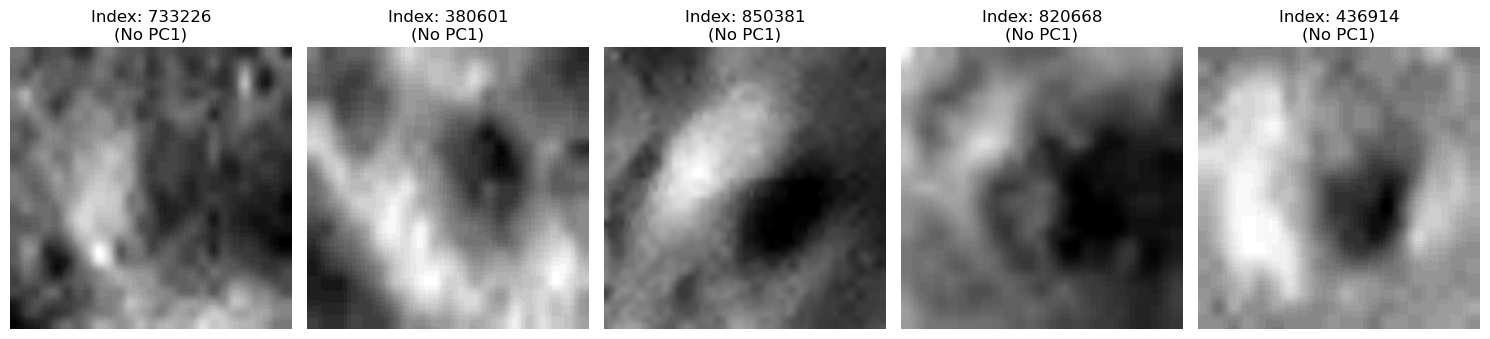

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- PATHS ---

# Use the path to your NEW reconstructed file
RECON_PATH = 'data/processed_sigma/200/craters.npy'
IMAGE_SIZE = 224

# 1. Open the file in read-only mode (doesn't load the whole file into RAM)
if not os.path.exists(RECON_PATH):
    print(f"File not found: {RECON_PATH}")
else:
    # We must provide the shape and dtype to memmap so it knows how to read the bytes
    # Get N by checking file size vs expected image size
    file_size = os.path.getsize(RECON_PATH)
    N = file_size // (1 * IMAGE_SIZE * IMAGE_SIZE * 4) # 4 bytes for float32
    
    reconstructed_data = np.memmap(
        RECON_PATH, 
        dtype='float32', 
        mode='r', 
        shape=(N, 1, IMAGE_SIZE, IMAGE_SIZE)
    )

    print(f"Successfully mapped {N:,} reconstructed craters.")

    # 2. Pick 5 random craters to inspect
    indices = np.random.choice(N, 5, replace=False)

    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(indices):
        # Access the crater (memmap only reads this specific chunk from disk)
        img = reconstructed_data[idx, 0, :, :]
        
        plt.subplot(1, 5, i + 1)
        plt.imshow(img, cmap='gray', vmin=img.min(), vmax=img.max())
        plt.title(f"Index: {idx}\n(No PC1)")
        plt.axis('off')
        
        # Print stats for each sample to check if they are in [0, 1]
        print(f"Crater {idx} - Min: {img.min():.4f}, Max: {img.max():.4f}, Mean: {img.mean():.4f}")

    plt.tight_layout()
    plt.show()

In [ ]:
python3 src/train/train.py \
    --autoencoder_model 'mae' \
    --input "data/processed_new/cae/craters_no_pc1_exact.npy" \
    --model_output "logs/pca_only/full_components/autoencoder_mae.pth" \
    --loss_plot logs/pca_only/full_components/loss_curve_mae.png" \
    --epochs 25 \
    --batch_size 64 \
    --latent_dim 40 \
    --lr 1e-3 \
    --lr_patience 3 \
    --min_lr 1e-5 \
    --lr_factor 0.5 \
    --num_samples 50000 \
    --weight_decay 1e-5 \
    --freeze_until 0 \
    --mask_ratio 0.75 


PYTHONPATH=. python3 src/train/reconstruct.py \
    --autoencoder_model cae \
    --input "data/processed_new/cae/craters_no_pc1_exact.npy" \
    --model "logs/pca_only/full_components/autoencoder_cae.pth" \
    --device "cpu" \
    --file_outq "logs/pca_only/full_components/reconstructions_cae.png" \
    --num_images 5 \
    --latent_dim 40 \
    --freeze_until 0 \
    --mask_ratio 0.75

PYTHONPATH=. python src/cluster/cluster.py encode \
    --imgs-dir "data/raw/craters_for_danny" \
    --model "logs/pca_only/full_components/autoencoder_cae.pth" \
    --bottleneck 40 \
    --out-latents "logs/pca_only/full_components/julie_vectors_cae.npy" \
    --out-states "logs/pca_only/full_components/julie_states_cae.npy" \
    --freeze-until 0 \
    --autoencoder-model cae \
    --mask-ratio 0.75 \
    --pretrained-model None

PYTHONPATH=. python src/cluster/cluster.py plot-dots \
    --latents "logs/pca_only/full_components/julie_vectors_cae.npy" \
    --states "logs/pca_only/full_components/julie_states_cae.npy" \
    --out-png "logs/pca_only/full_components/julie_dots_cae.png" \
    --model-name cae \
    --technique pca

PYTHONPATH=. python src/cluster/cluster.py plot-imgs \
    --latents "logs/pca_only/full_components/julie_vectors_cae.npy" \
    --imgs-dir "data/raw/craters_for_danny" \
    --out-png "logs/pca_only/full_components/julie_plot_imgs_cae.png" \
    --model-name cae \
    --technique pca

In [ ]:
python3 src/train/train.py \
    --autoencoder_model 'mae' \
    --input "data/processed_new/cae/craters_no_pc1_exact.npy" \
    --model_output "logs/pca_only/full_components/autoencoder_mae.pth" \
    --loss_plot logs/pca_only/full_components/loss_curve_mae.png" \
    --epochs 25 \
    --batch_size 64 \
    --latent_dim 40 \
    --lr 1e-3 \
    --lr_patience 3 \
    --min_lr 1e-5 \
    --lr_factor 0.5 \
    --num_samples 50000 \
    --weight_decay 1e-5 \
    --freeze_until 0 \
    --mask_ratio 0.75 

PYTHONPATH=. python3 src/train/reconstruct.py \
    --autoencoder_model mae \
    --input "data/processed_new/cae/craters_no_pc1_exact.npy" \
    --model "logs/pca_only/full_components/autoencoder_mae.pth" \
    --device "cpu" \
    --file_outq "logs/pca_only/full_components/reconstructions_mae.png" \
    --num_images 5 \
    --latent_dim 40 \
    --freeze_until 0 \
    --mask_ratio 0.75

PYTHONPATH=. python src/cluster/cluster.py encode \
    --imgs-dir "data/raw/craters_for_danny" \
    --model "logs/pca_only/full_components/autoencoder_mae.pth" \
    --bottleneck 40 \
    --out-latents "logs/pca_only/full_components/julie_vectors.npy" \
    --out-states "logs/pca_only/full_components/julie_states.npy" \
    --freeze-until 0 \
    --autoencoder-model mae \
    --mask-ratio 0.75 \
    --pretrained-model None

PYTHONPATH=. python src/cluster/cluster.py plot-dots \
    --latents "logs/pca_only/full_components/julie_vectors.npy" \
    --states "logs/pca_only/full_components/julie_states.npy" \
    --out-png "logs/pca_only/full_components/julie_dots.png" \
    --model-name mae \
    --technique pca

PYTHONPATH=. python src/cluster/cluster.py plot-imgs \
    --latents "logs/pca_only/full_components/julie_vectors.npy" \
    --imgs-dir "data/raw/craters_for_danny" \
    --out-png "logs/pca_only/full_components/julie_plot_imgs_mae.png" \
    --model-name mae \
    --technique pca

PYTHONPATH=. python3 src/display/display.py \
    --model_path "logs/pca_only/full_components/autoencoder_mae.pth" \
    --dataset_path "data/processed_new/cae/craters_no_pc1_exact.npy" \
    --metadata_path "data/processed_new/cae/metadata.csv" \
    --num_clusters 4 \
    --batch_size 32 \
    --device "cpu" \
    --latent_dim 40 \
    --out_df "logs/pca_only/full_components/craters_no_pca1_mae_kmeans.csv" \
    --cluster_method "kmeans" \
    --technique "pca" \
    --latent_output "logs/pca_only/full_components/mae_no_pc1_latent_vectors.npy" \
    --autoencoder_model mae \
    --freeze_until 0\
    --use_gpu \
    --pretrained_model None


In [ ]:
PYTHONPATH=. python3 src/train/train.py \
    --autoencoder_model 'mae' \
    --input "data/processed_wac_100m_new/sigma/100/craters.npy" \
    --model_output "logs/mae/bottleneck_64/processed_sigma/100/autoencoder.pth" \
    --loss_plot "logs/mae/bottleneck_64/processed_sigma/100/loss_curve.png" \
    --epochs 50 \
    --batch_size 64 \
    --latent_dim 64 \
    --lr 1e-3 \
    --lr_patience 3 \
    --min_lr 1e-5 \
    --lr_factor 0.5 \
    --num_samples 50000 \
    --weight_decay 1e-5 \
    --freeze_until 0 \
    --mask_ratio 0.75 

PYTHONPATH=. python3 src/train/reconstruct.py \
    --autoencoder_model mae \
    --input "data/processed_wac_100m_new/sigma/100/craters.npy" \
    --model "logs/mae/bottleneck_64/processed_sigma/100/autoencoder.pth" \
    --device "cpu" \
    --file_outq "logs/mae/bottleneck_64/processed_sigma/100/reconstructions.png" \
    --num_images 5 \
    --latent_dim 64 \
    --freeze_until 0 \
    --mask_ratio 0.75

PYTHONPATH=. python src/cluster/cluster.py encode \
    --imgs-dir "data/raw/craters_for_danny" \
    --model "logs/mae/bottleneck_64/processed_sigma/100/autoencoder.pth" \
    --bottleneck 64 \
    --out-latents "logs/mae/bottleneck_64/processed_sigma/100/julie_vectors.npy" \
    --out-states "logs/mae/bottleneck_64/processed_sigma/100/julie_states.npy" \
    --freeze-until 0 \
    --autoencoder-model mae \
    --mask-ratio 0.75 \
    --pretrained-model None

PYTHONPATH=. python src/cluster/cluster.py plot-dots \
    --latents "logs/mae/bottleneck_64/processed_sigma/100/julie_vectors.npy" \
    --states "logs/mae/bottleneck_64/processed_sigma/100/julie_states.npy" \
    --out-png "logs/mae/bottleneck_64/processed_sigma/100/julie_dots.png" \
    --model-name mae \
    --technique pca

PYTHONPATH=. python src/cluster/cluster.py plot-imgs \
    --latents "logs/mae/bottleneck_64/processed_sigma/100/julie_vectors.npy" \
    --imgs-dir "data/raw/craters_for_danny" \
    --out-png "logs/mae/bottleneck_64/processed_sigma/100/julie_plot_imgs_mae.png" \
    --model-name mae \
    --technique pca


PYTHONPATH=. python3 src/display/display.py \
    --model_path "logs/mae/bottleneck_64/processed_sigma/100/autoencoder.pth" \
    --dataset_path "data/processed_wac_100m_new/sigma/100/craters.npy" \
    --metadata_path "data/processed_wac_100m_new/sigma/100/metadata.csv" \
    --num_clusters 4 \
    --batch_size 32 \
    --device "cpu" \
    --latent_dim 40 \
    --out_df "logs/mae/bottleneck_64/processed_sigma/100/craters_kmeans_4.csv" \
    --cluster_method "kmeans" \
    --technique "pca" \
    --latent_output "logs/mae/bottleneck_64/processed_sigma/100/full_latent_vectors.npy" \
    --autoencoder_model 'mae' \
    --freeze_until 0\
    --use_gpu \
    --pretrained_model None


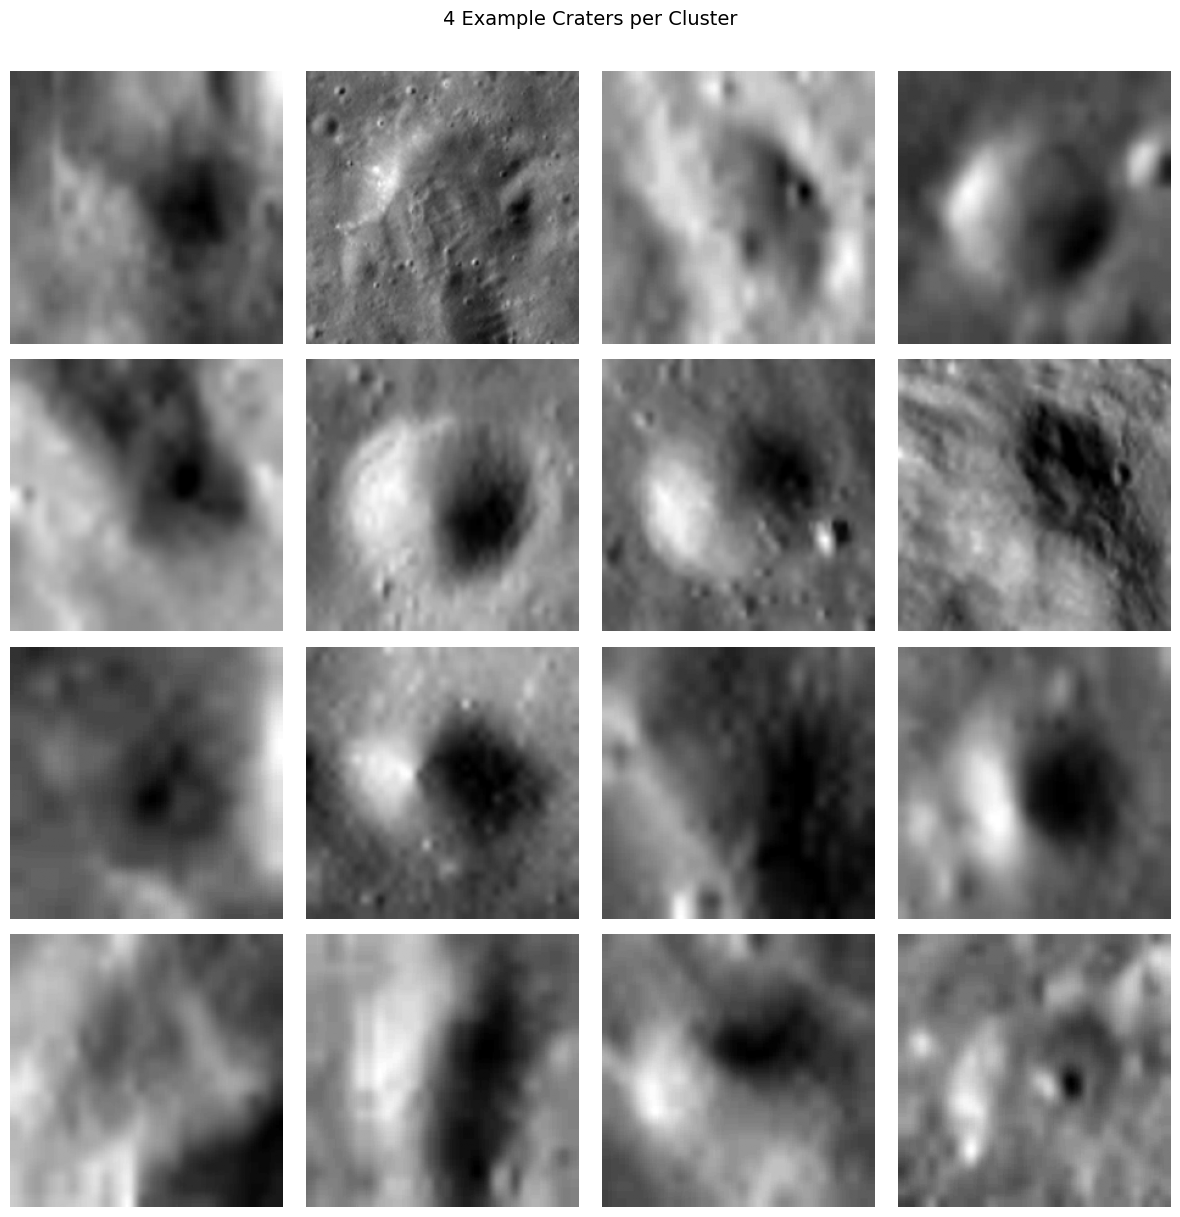

Saved to craters_by_cluster.png


In [ ]:
"""
Plot 4 example craters from each k-means cluster
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
import os
crater_path = 'data/processed_sigma/200/craters.npy'
file_size = os.path.getsize(crater_path)
N = file_size // (224 * 224 * 1 * 4)
craters = np.memmap(crater_path, dtype=np.float32, mode="r", shape=(N, 1, 224, 224))

df = pd.read_csv("logs/mae/processed_sigma/200/craters_kmeans_4.csv")  # x, y, cluster

n_clusters = 4
n_examples = 4

fig, axes = plt.subplots(n_clusters, n_examples, figsize=(n_examples * 3, n_clusters * 3))

for cluster_id in range(n_clusters):
    # Get random indices of craters in this cluster
    idx = df[df["cluster"] == cluster_id].sample(n=n_examples).index.tolist()
    
    for col, i in enumerate(idx):
        ax = axes[cluster_id, col]
        img = craters[i, 0]  # shape (224, 224)
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(f"Cluster {cluster_id}", fontsize=12, loc="left")

plt.suptitle("4 Example Craters per Cluster", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("craters_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to craters_by_cluster.png")

In [ ]:
PYTHONPATH=. python3 src/train/reconstruct.py \
    --autoencoder_model cae \
    --input "data/processed_new/cae/craters_no_pc1_exact.npy" \
    --model "logs/pca_only/full_components/autoencoder_cae.pth" \
    --device "cpu" \
    --file_outq "logs/pca_only/full_components/reconstructions_cae.png" \
    --num_images 5 \
    --latent_dim 40 \
    --freeze_until 0 \
    --mask_ratio 0.75

PYTHONPATH=. python3 src/display/display.py \
    --model_path "logs/pca_only/full_components/autoencoder_cae.pth" \
    --dataset_path "data/processed_new/cae/craters_no_pc1_exact.npy" \
    --metadata_path "data/processed_new/cae/metadata.csv" \
    --num_clusters 4 \
    --batch_size 32 \
    --device "cpu" \
    --latent_dim 40 \
    --out_df "logs/pca_only/full_components/craters_no_pca1_kmeansa.csv" \
    --cluster_method "kmeans" \
    --technique "pca" \
    --latent_output "logs/pca_only/full_components/cae_no_pc1_latent_vectors.npy" \
    --autoencoder_model cae \
    --freeze_until 0\
    --use_gpu \
    --pretrained_model None



In [ ]:
        PYTHONPATH=. python src/data/preprocess.py \
            --map_file {input.map_file} \
            --craters_csv {input.craters_csv} \
            --output_dir {output.output_dir} \
            --np_output_path {output.np_output} \
            --info_output_path {output.metadata_output} \
            --min_diameter {params.min_diameter} \
            --max_diameter {params.max_diameter} \
            --latitude_bounds {params.lat_min} {params.lat_max} \
            --offset {params.offset} \
            --craters_to_output {params.craters_to_output} \
            --save_raw_crops \
            --save_np_array \
            --autoencoder_model {params.autoencoder_model} \
            --target_size {params.target_size}
        """

CRS: PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",1737400,0]],PRIMEM["Reference meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds: BoundingBox(left=-5458203.076346907, bottom=-1819401.025448969, right=5458203.076346907, top=1819401.0254489686)
Shape: 36388 x 109164
Reflectance range: -0.0544 – 0.0856


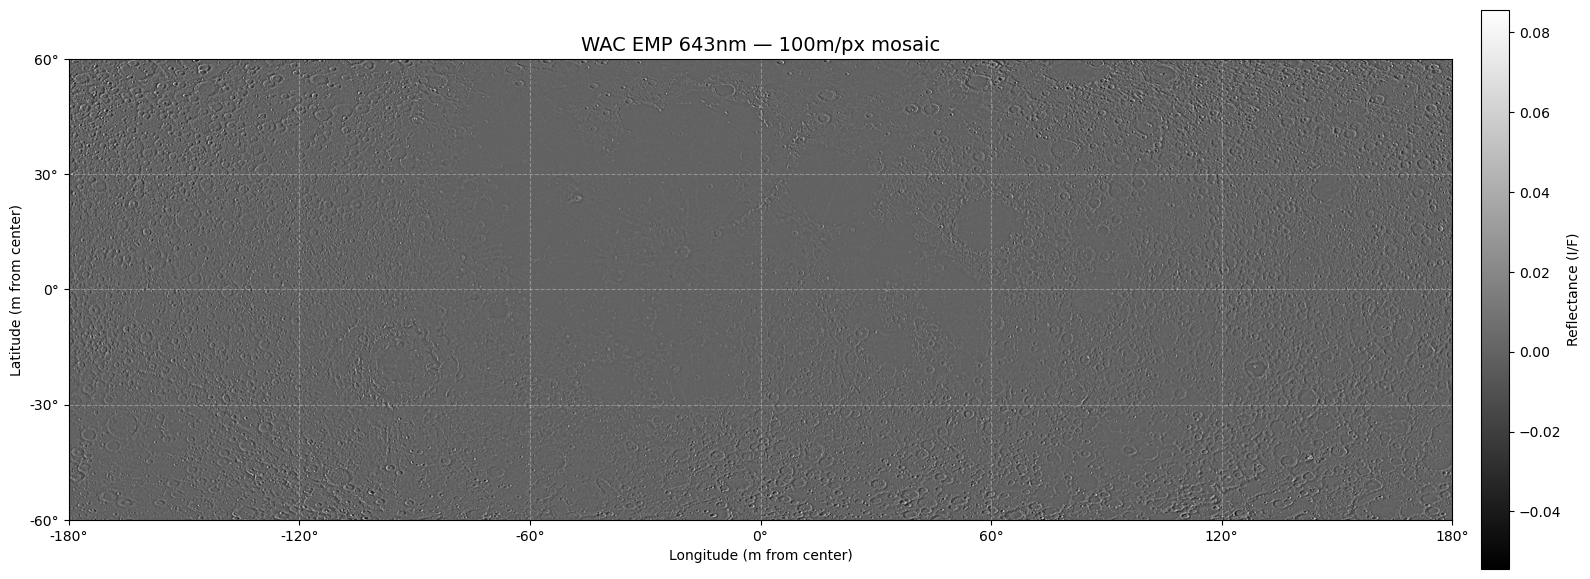

In [16]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open("data/raw/wac_mosaic_new_version/sigma/100/highpass_filtered_lunar_mosaic.tif") as src:
    # Read a downsampled version (1/20th resolution) for quick preview
    data = src.read(1, out_shape=(src.height // 20, src.width // 20))
    bounds = src.bounds
    crs = src.crs

# Mask nodata
data = np.ma.masked_less(data, -1e37)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(data, cmap='gray', interpolation='bilinear',
               extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

plt.colorbar(im, ax=ax, label='Reflectance (I/F)', fraction=0.02, pad=0.02)
ax.set_title('WAC EMP 643nm — 100m/px mosaic', fontsize=14)
ax.set_xlabel('Longitude (m from center)')
ax.set_ylabel('Latitude (m from center)')

# Add lon/lat grid labels manually
xticks = np.linspace(bounds.left, bounds.right, 7)
xlabels = [f'{int(v)}°' for v in np.linspace(-180, 180, 7)]
yticks = np.linspace(bounds.bottom, bounds.top, 5)
ylabels = [f'{int(v)}°' for v in np.linspace(-60, 60, 5)]
ax.set_xticks(xticks); ax.set_xticklabels(xlabels)
ax.set_yticks(yticks); ax.set_yticklabels(ylabels)
ax.grid(True, alpha=0.3, color='white', linestyle='--')

plt.tight_layout()
plt.savefig('mosaic_preview.png', dpi=150, bbox_inches='tight')
print(f"CRS: {crs}")
print(f"Bounds: {bounds}")
print(f"Shape: {src.height} x {src.width}")
print(f"Reflectance range: {data.min():.4f} – {data.max():.4f}")

In [17]:
import rasterio
import numpy as np
from rasterio.transform import from_bounds

with rasterio.open("data/raw/wac_mosaic_new_version/sigma/100/highpass_filtered_lunar_mosaic.tif") as src:
    data = src.read(1)
    profile = src.profile
    bounds = src.bounds
    
print(f"Shape: {data.shape}")
print(f"Bounds: {bounds}")
print(f"Non-nodata columns on left half: {np.sum(data[:, :data.shape[1]//2] > -1e37)}")
print(f"Non-nodata columns on right half: {np.sum(data[:, data.shape[1]//2:] > -1e37)}")

Shape: (36388, 109164)
Bounds: BoundingBox(left=-5458203.076346907, bottom=-1819401.025448969, right=5458203.076346907, top=1819401.0254489686)
Non-nodata columns on left half: 1986129816
Non-nodata columns on right half: 1986129816


In [1]:
import numpy as np
import os

path = 'data/processed_wac_100m_new/sigma/100/craters.npy'
file_size = os.path.getsize(path)
N = file_size // (224 * 224 * 1 * 4)
d = np.memmap(path, dtype=np.float32, mode='r', shape=(N, 1, 224, 224))
print(f'N={N}')
print(f'mean={d.mean():.4f}')
print(f'min={d.min():.4f}')
print(f'max={d.max():.4f}')
print(f'std={d.std():.4f}')

N=152103
mean=0.0003
min=-0.0931
max=0.1065
std=0.0171


In [2]:
import numpy as np
from sklearn.decomposition import PCA

latents = np.load('logs/mae/processed_wac_100m_new/sigma/100/full_latent_vectors.npy')
print(f"Latents shape: {latents.shape}")
print(f"Latents mean: {latents.mean():.4f}")
print(f"Latents std: {latents.std():.4f}")

pca = PCA(n_components=10)
pca.fit(latents)
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {v*100:.1f}%")

Latents shape: (152103, 768)
Latents mean: -0.0003
Latents std: 0.4443
PC1: 46.2%
PC2: 35.8%
PC3: 4.5%
PC4: 2.8%
PC5: 2.2%
PC6: 1.5%
PC7: 1.2%
PC8: 1.1%
PC9: 0.9%
PC10: 0.5%


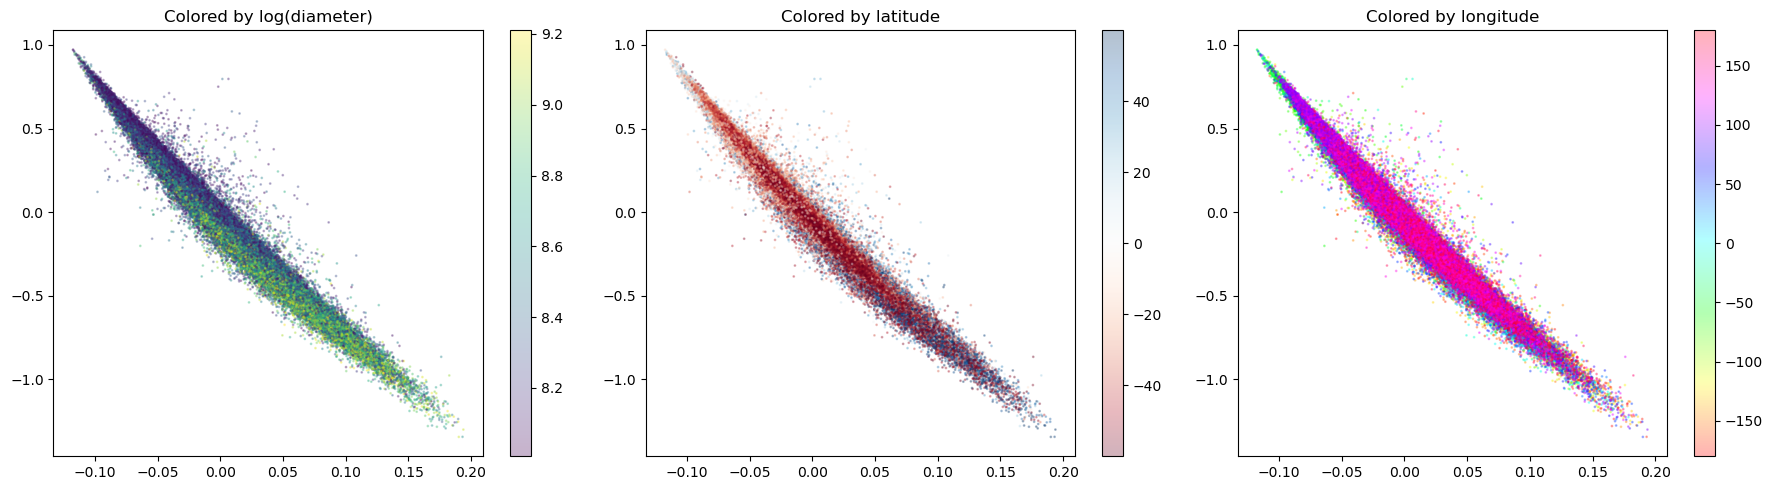

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

latents = np.load('logs/mae/processed_wac_100m_new/sigma/100/full_latent_vectors.npy')
metadata = pd.read_csv('data/processed_wac_100m_new/sigma/100/metadata.csv')  # with diam, lat, lon

pca = PCA(n_components=2)
coords = pca.fit_transform(latents)

# Plot colored by log diameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By diameter
sc = axes[0].scatter(coords[:,0], coords[:,1], 
    c=np.log(metadata['diam']), cmap='viridis', s=1, alpha=0.3)
plt.colorbar(sc, ax=axes[0])
axes[0].set_title('Colored by log(diameter)')

# By latitude  
sc = axes[1].scatter(coords[:,0], coords[:,1],
    c=metadata['lat'], cmap='RdBu', s=1, alpha=0.3)
plt.colorbar(sc, ax=axes[1])
axes[1].set_title('Colored by latitude')

# By longitude
sc = axes[2].scatter(coords[:,0], coords[:,1],
    c=metadata['lon'], cmap='hsv', s=1, alpha=0.3)
plt.colorbar(sc, ax=axes[2])
axes[2].set_title('Colored by longitude')

plt.tight_layout()
plt.savefig('pca_colored_diagnostics.png', dpi=200)

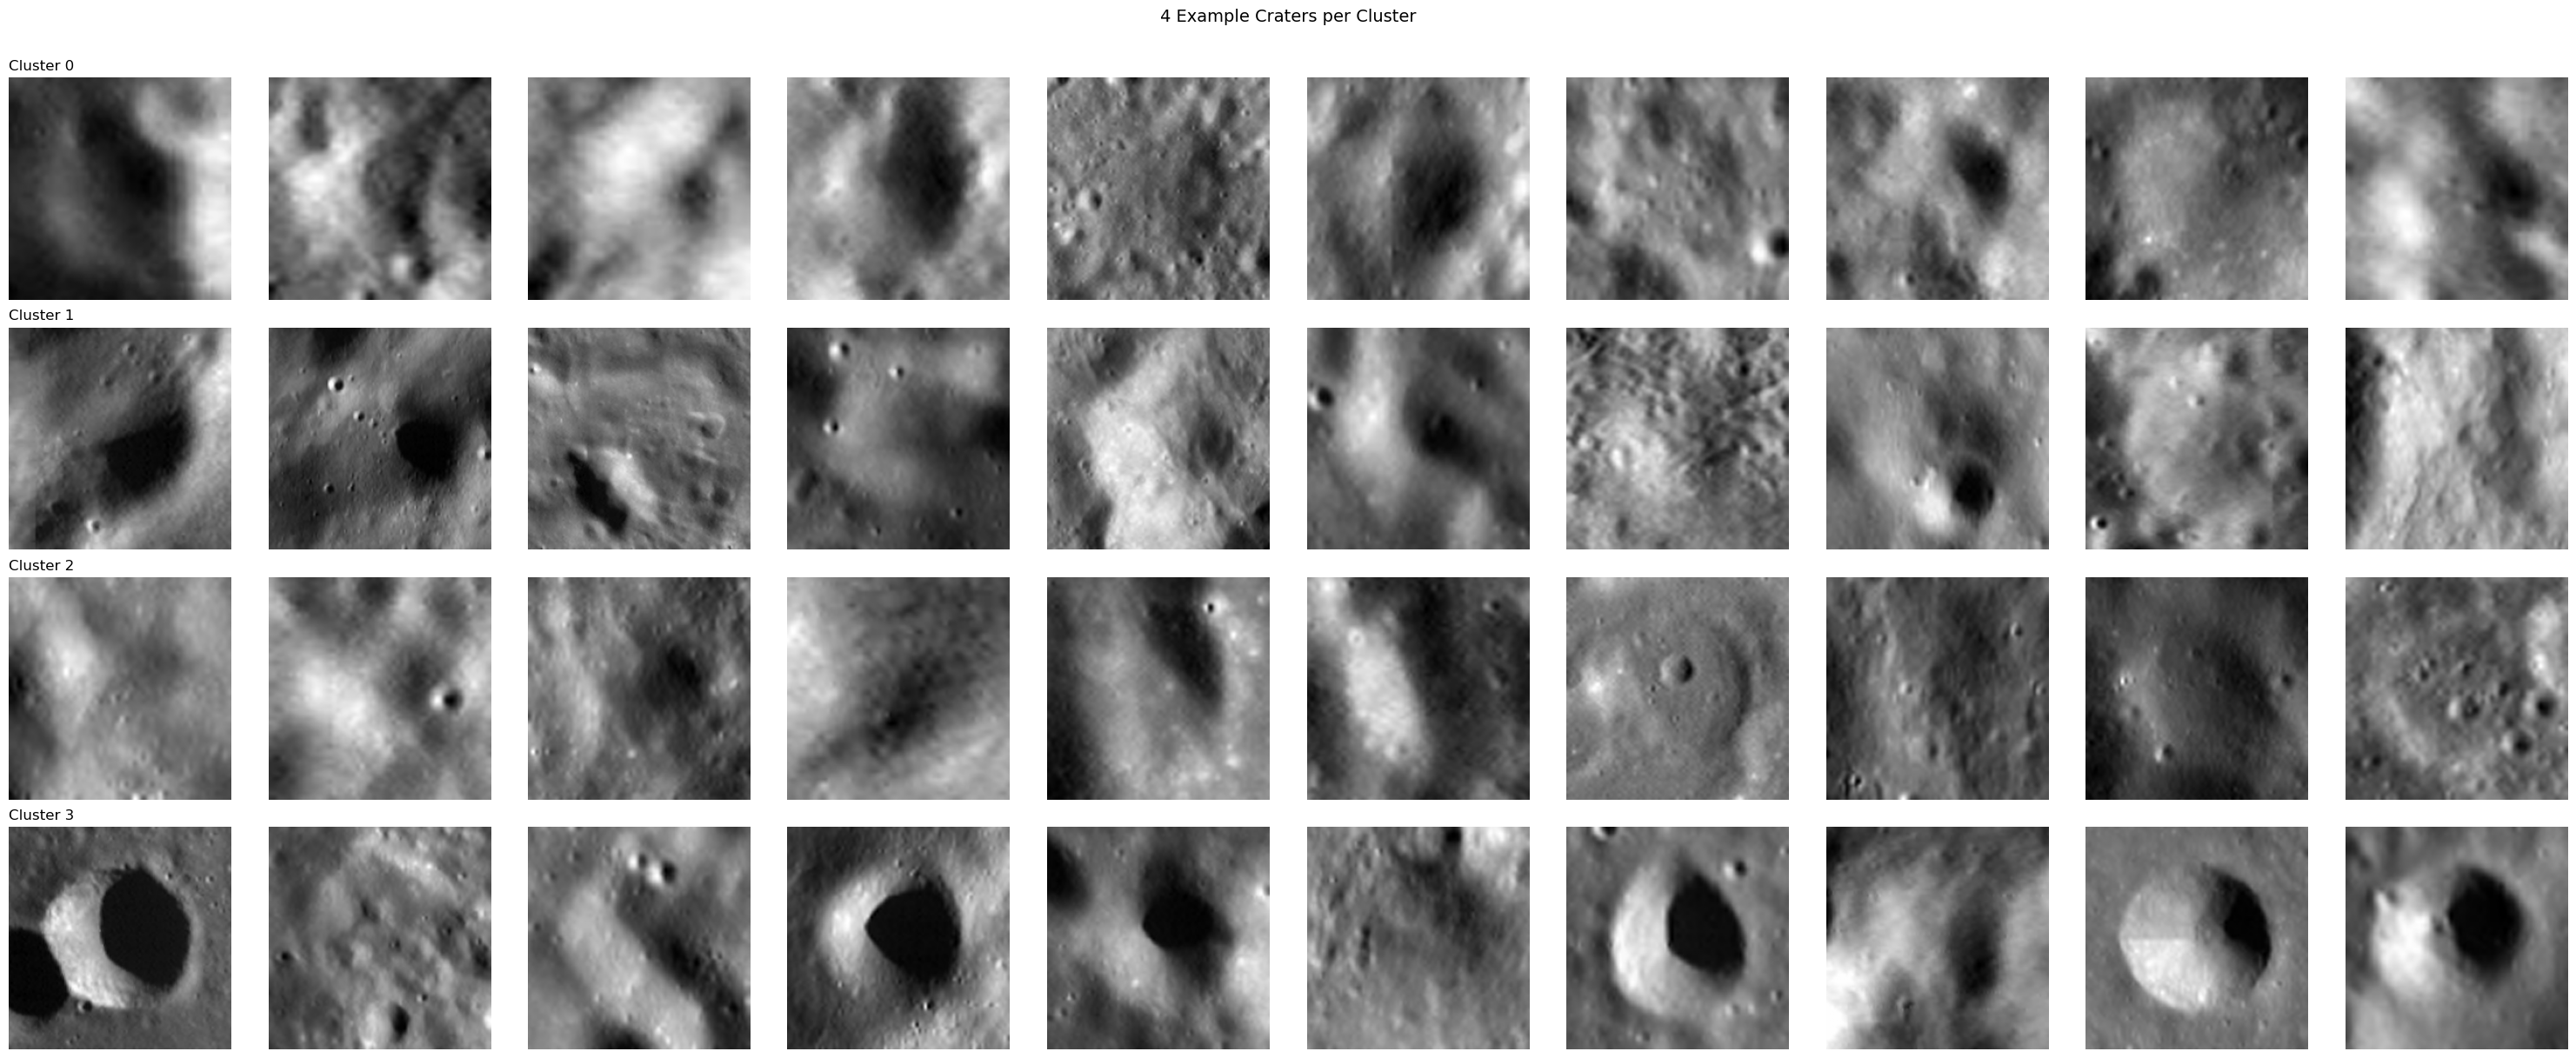

Saved to craters_by_cluster.png


In [15]:
"""
Plot 4 example craters from each k-means cluster
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
import os
crater_path = "data/processed_wac_100m_new/sigma/100/craters.npy"
file_size = os.path.getsize(crater_path)
N = file_size // (224 * 224 * 1 * 4)
craters = np.memmap(crater_path, dtype=np.float32, mode="r", shape=(N, 1, 224, 224))

df = pd.read_csv("logs/mae/processed_wac_100m_new/sigma/100/craters_kmeans_4.csv")  # x, y, cluster

n_clusters = 4
n_examples = 10

fig, axes = plt.subplots(n_clusters, n_examples, figsize=(n_examples * 3, n_clusters * 3))

for cluster_id in range(n_clusters):
    # Get random indices of craters in this cluster
    idx = df[df["cluster"] == cluster_id].sample(n=n_examples).index.tolist()
    
    for col, i in enumerate(idx):
        ax = axes[cluster_id, col]
        img = craters[i, 0]  # shape (224, 224)
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(f"Cluster {cluster_id}", fontsize=12, loc="left")

plt.suptitle("4 Example Craters per Cluster", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("craters_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to craters_by_cluster.png")